In [25]:
%reload_ext autoreload
%autoreload 2

import importlib

import numpy as np
import matplotlib.pyplot as plt
import state_to_edgepoints as state_to_edgepoints_module

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)
state_to_edgepoints = state_to_edgepoints_module.state_to_edgepoints

import sys

# go out of folder to import the CR alg
sys.path.append("..")

from filters import ChristianRobinson 



from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose

from filters import SatEKF


from InterfaceWrapperFuncs import Set_camera, gen_traj, plot_traj, get_images,run_step, get_tpc, plot_est_dist_xyz, plot_est_dist_xyz_errors

In [10]:
f, mu, n_pixels = Set_camera() #Sagitta camera parameters


# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
moon_radius = 1737.4 # km
moon_mu = 4902.800066 # km^3/s^2

body = Body(a=moon_radius, b=moon_radius, c=moon_radius)
#print(camera)
print(body)


w, h = 1280, 720
K = np.array(
    [
        [1120.0, 0.0, w / 2.0],
        [0.0, 1120.0, h / 2.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

k_inv = np.linalg.inv(K)

camera_spec_ellie = {
    "K": K,
    "width": w,
    "height": h,
}

camera_spec_ellie2 = {
    "K": np.linalg.inv(camera.K_inv),
    "width": camera.resolution[0],
    "height": camera.resolution[1],
}

cr_alg = ChristianRobinson(k_inv, body.a, body.b, body.c)


Worldview:
 - Ellipsoid semi-axes a,b,c = [1737.4, 1737.4, 1737.4] km



Orbital period (T): 164927.14738070985s


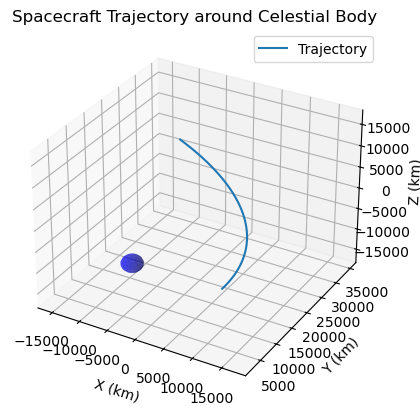

84
0


In [17]:
pos = np.array([15000, 400, 100])
r = np.linalg.norm(pos)
v = np.sqrt( moon_mu / r) + 0.2 # km/s, slightly
State0 = [pos[0], pos[1], pos[2], 0, v, 0] 



dt = 1000
op, body_struct = gen_traj(Starting_state=State0, dt=dt)
plot_traj(op, body_struct)

print(len(op.states))
print(op.ts[0])


In [18]:
# for 10 points along traj gen images and test CR alg
cam_offset = np.array([5, 5, 0]) # no offset for now
images, edges, outs, states, times = get_images(op, body_struct, cam_offset, camera_spec_ellie, 84)


State at t=0.0s: [1.500e+04 4.000e+02 1.000e+02 0.000e+00 7.716e-01 0.000e+00]
State at t=0.0s: [1.500e+04 4.000e+02 1.000e+02 0.000e+00 7.716e-01 0.000e+00]
State at t=1000.0s: [ 1.499e+04  1.171e+03  9.993e+01 -2.171e-02  7.705e-01 -1.447e-04]
State at t=2000.0s: [ 1.496e+04  1.941e+03  9.971e+01 -4.322e-02  7.682e-01 -2.881e-04]
State at t=3000.0s: [ 1.490e+04  2.707e+03  9.935e+01 -6.443e-02  7.649e-01 -4.295e-04]
State at t=4000.0s: [ 1.483e+04  3.470e+03  9.885e+01 -8.525e-02  7.606e-01 -5.683e-04]
State at t=5000.0s: [ 1.473e+04  4.228e+03  9.822e+01 -1.056e-01  7.553e-01 -7.039e-04]
State at t=6000.0s: [ 1.462e+04  4.980e+03  9.745e+01 -1.253e-01  7.491e-01 -8.357e-04]
State at t=7000.0s: [ 1.448e+04  5.726e+03  9.655e+01 -1.445e-01  7.421e-01 -9.633e-04]
State at t=8000.0s: [ 1.433e+04  6.464e+03  9.552e+01 -1.629e-01  7.343e-01 -1.086e-03]
State at t=9000.0s: [ 1.416e+04  7.194e+03  9.438e+01 -1.807e-01  7.258e-01 -1.204e-03]
State at t=10000.0s: [ 1.397e+04  7.916e+03  9.311

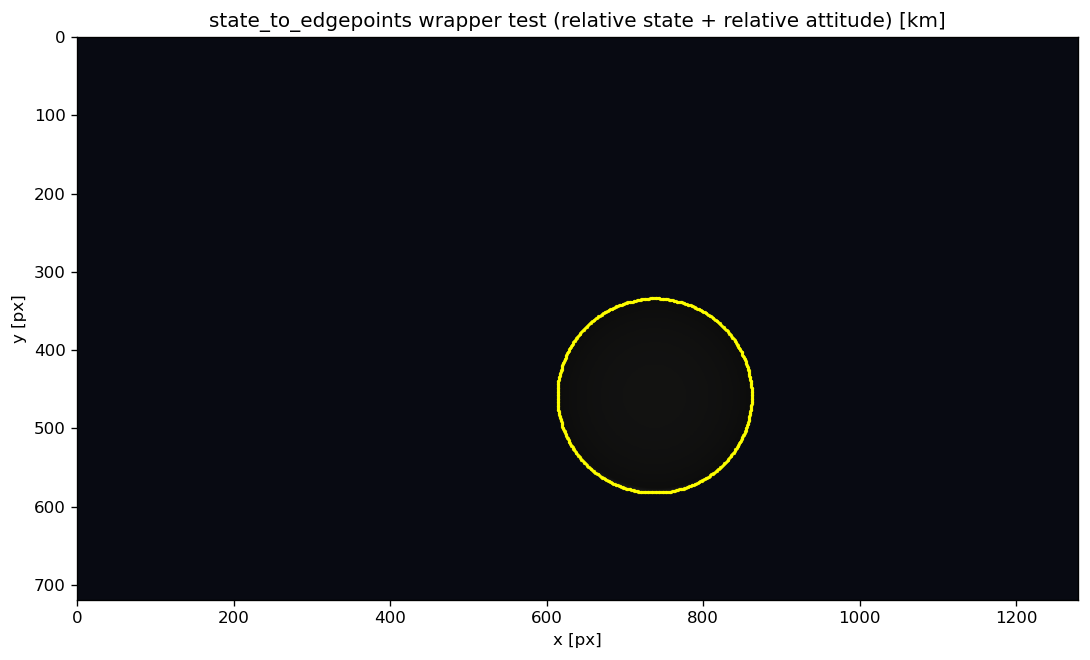

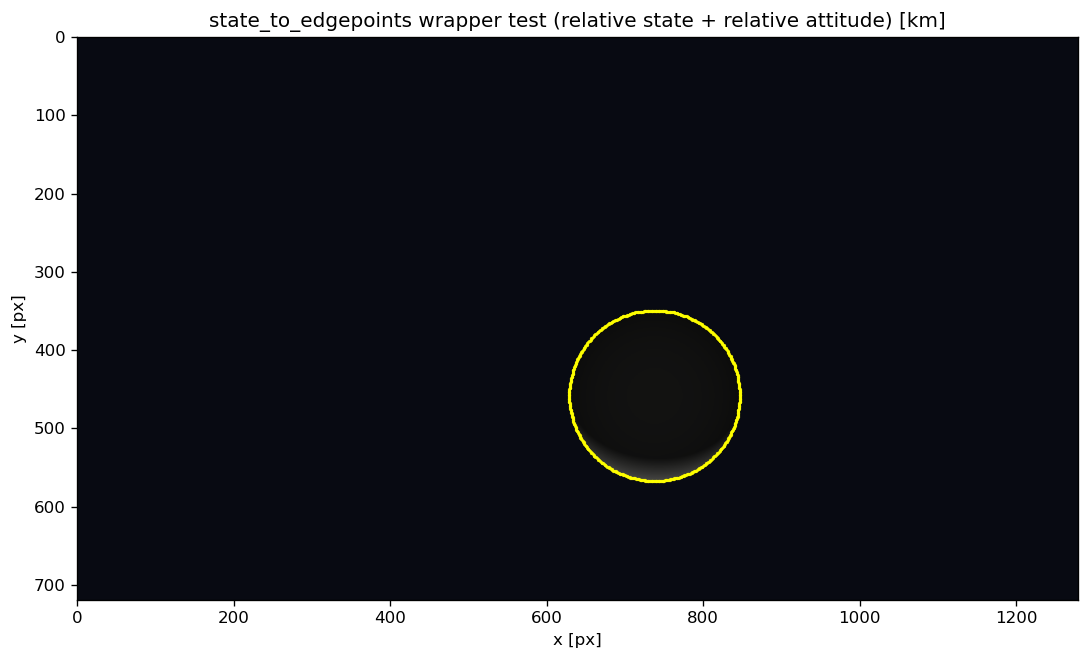

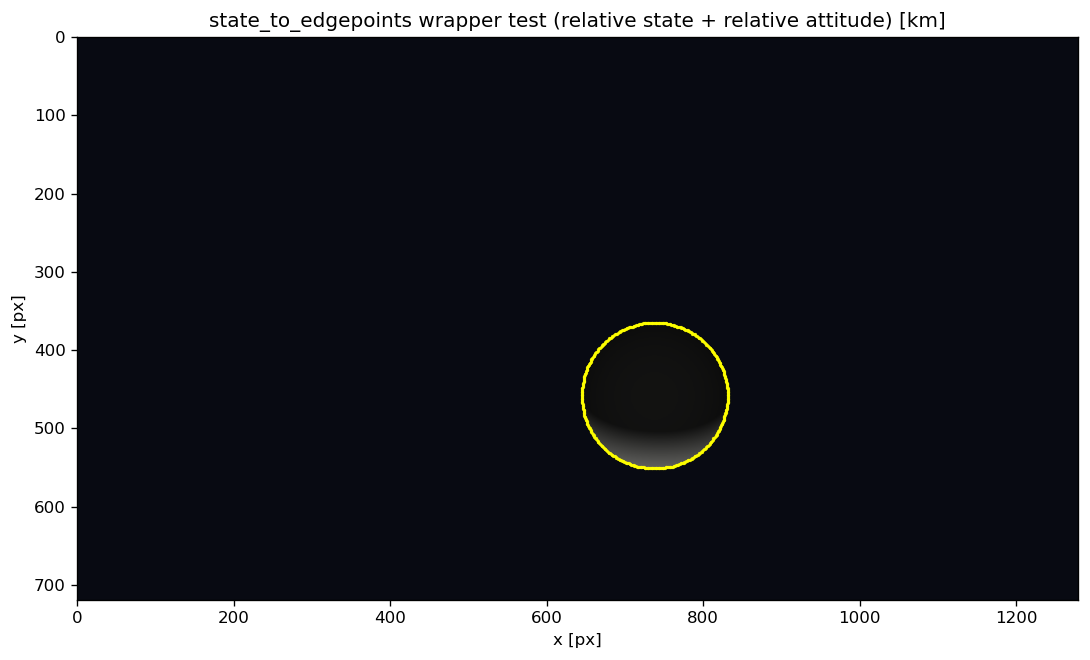

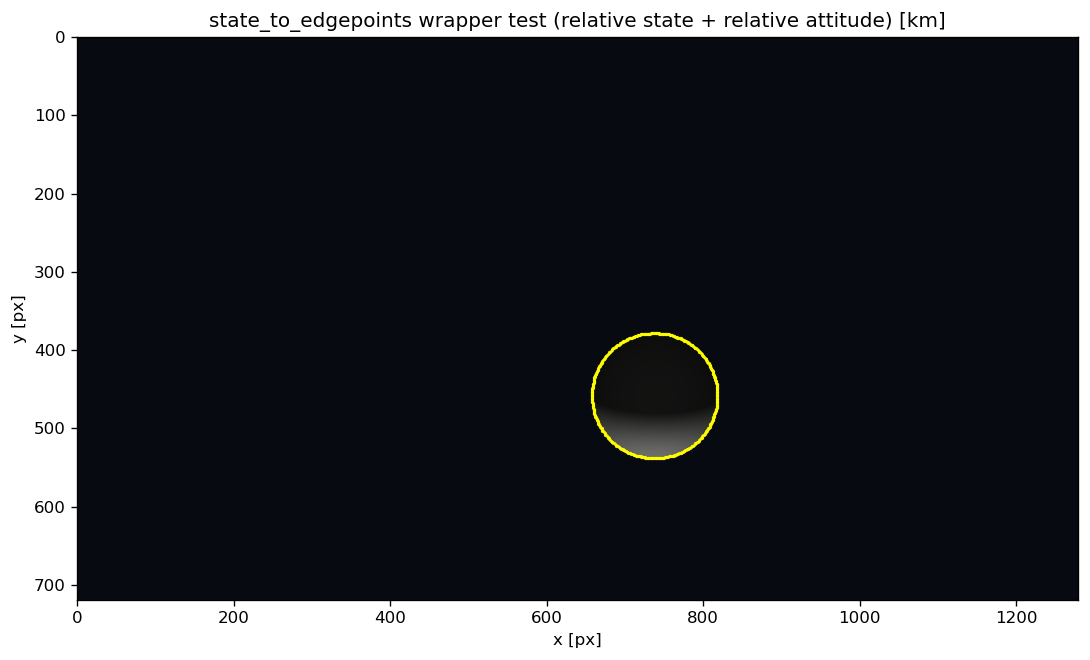

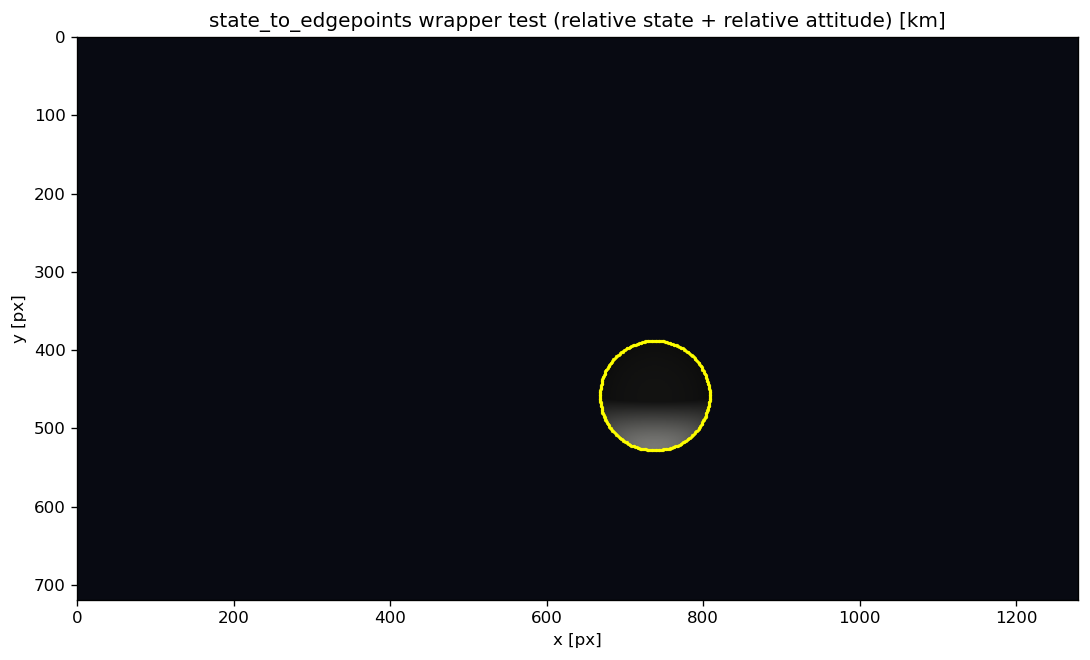

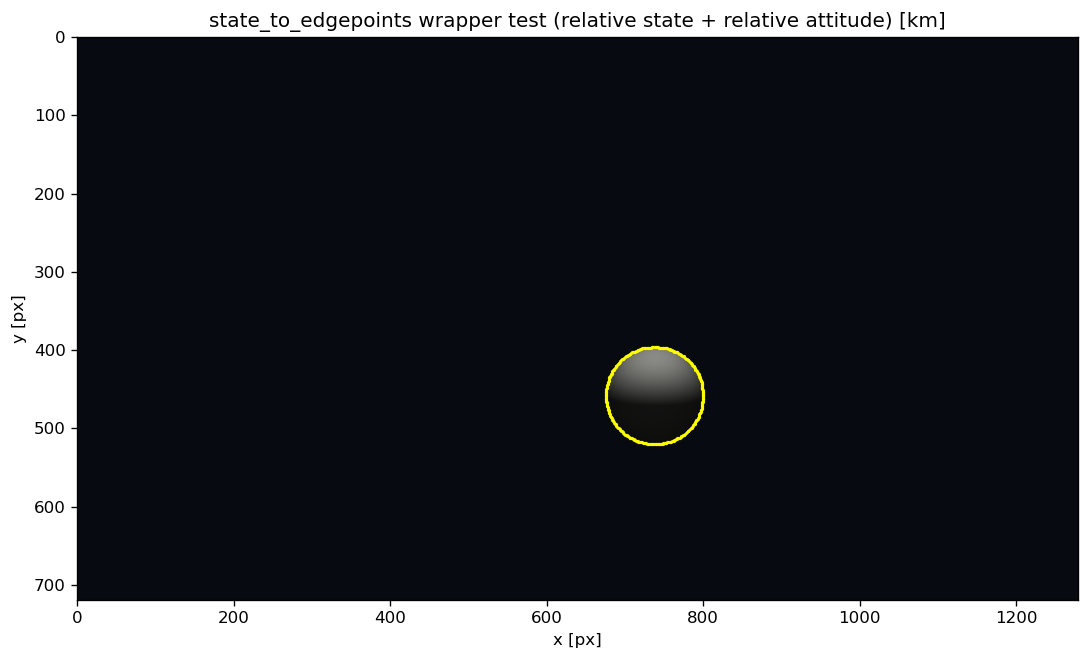

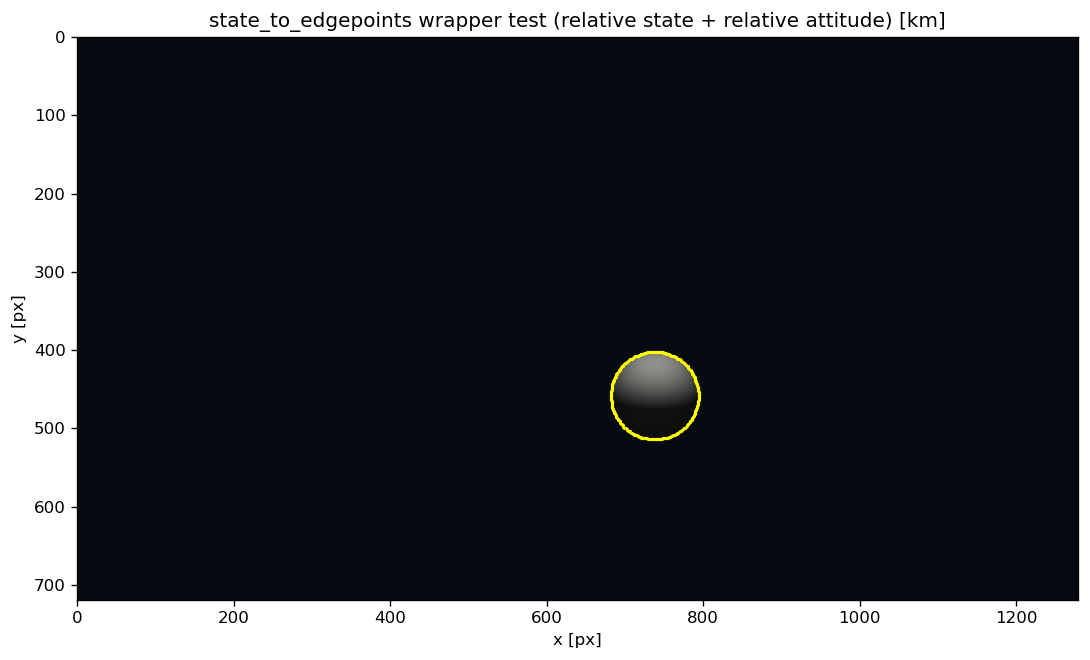

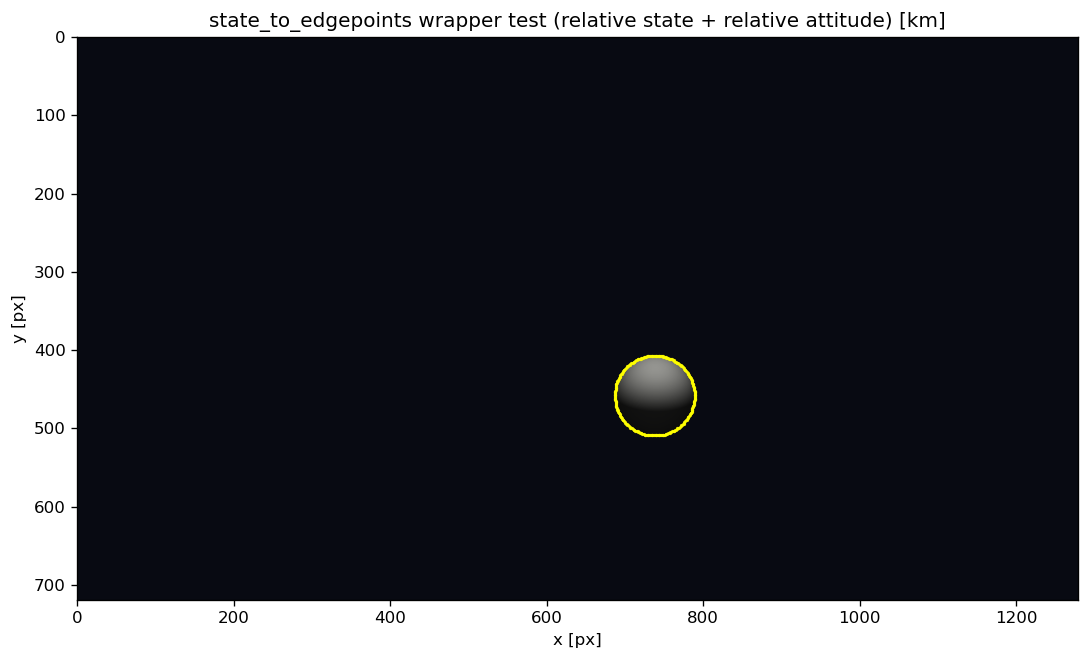

In [20]:
# plot the images and edge points with optional pixel-axis limits
x_limits = None  # e.g. (420, 860)
y_limits = None  # e.g. (560, 180) for image coordinates (inverted y)

i = 0
for out in outs:
    i += 1
    if i % 10 == 0:
        w, h = camera_spec_ellie["width"], camera_spec_ellie["height"]
        state_to_edgepoints_module.plot_edge_points(
            out,
            w,
            h,
            x_limits=x_limits,
            y_limits=y_limits,
        )

In [21]:

# Running Christian-Robinson algorithm on all images
# Note: Camera offset is now handled in get_images() via attitude_offset_from_center_pointing

estimates = []
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute planet-to-camera rotation matrix from render output
    tpc = get_tpc(out)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: estimates camera->planet vector in camera frame
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], tpc, print_stats=True, cr_alg=cr_alg)
    estimates.append(-rp_est)

Running CR alg on image 1/84
Calc Position:
 - (C->P in camera frame): [ 1304.96  1309.56 15114.95] (15227.60 km)
 - (C->P in planet frame): [-15222.41   -388.24    -84.12] (15227.60 km)
Actual position:
 - (C->P in camera frame): [ 1302.85  1307.83 14891.68] (15005.67 km)
 - (C->P in planet frame): [-15000.   -400.   -100.] (15005.67 km)
Est Error - Actual:
 - (Camera frame): [  2.1    1.73 223.27] (223.29 km)
 - (Planet frame): [-222.41   11.76   15.88] (223.29 km)
Distance error: 221.93 km (1.478973%)
Angular error: 0.0932 degrees
Running CR alg on image 2/84
Calc Position:
 - (C->P in camera frame): [ 1304.96  1309.56 15114.95] (15227.60 km)
 - (C->P in planet frame): [-15222.41   -388.24    -84.12] (15227.60 km)
Actual position:
 - (C->P in camera frame): [ 1302.85  1307.83 14891.68] (15005.67 km)
 - (C->P in planet frame): [-15000.   -400.   -100.] (15005.67 km)
Est Error - Actual:
 - (Camera frame): [  2.1    1.73 223.27] (223.29 km)
 - (Planet frame): [-222.41   11.76   15.88] 

(84, 3)
[  388.241   388.241  1171.818  1952.324  2730.884  3505.264  4274.84
  5039.496  5795.949  6546.633  7289.337  8022.219  8745.207  9460.434
 10161.992 10854.72  11536.825 12208.381 12867.463 13514.465 14150.543
 14774.829 15387.99  15989.914 16582.87  17159.039 17728.92  18285.217
 18833.685 19371.47  19891.049 20409.756 20918.179 21412.944 21894.2
 22370.965 22837.19  23303.805 23747.978 24189.325 24627.434 25046.176
 25465.58  25874.565 26278.479 26661.747 27060.951 27436.466 27812.583
 28185.315 28545.269 28897.748 29239.371 29586.267 29921.364 30250.937
 30574.211 30904.203 31210.848 31518.007 31834.249 32120.87  32420.273
 32705.65  32994.58  33265.918 33541.81  33826.717 34101.413 34348.793
 34600.224 34861.643 35110.687 35360.652 35610.219 35852.133 36085.255
 36306.491 36550.662 36760.617 37005.312 37217.826 37415.703 37649.83 ]
times: [    0     0  1000  2000  3000  4000  5000  6000  7000  8000  9000 10000
 11000 12000 13000 14000 15000 16000 17000 18000 19000 20000 2

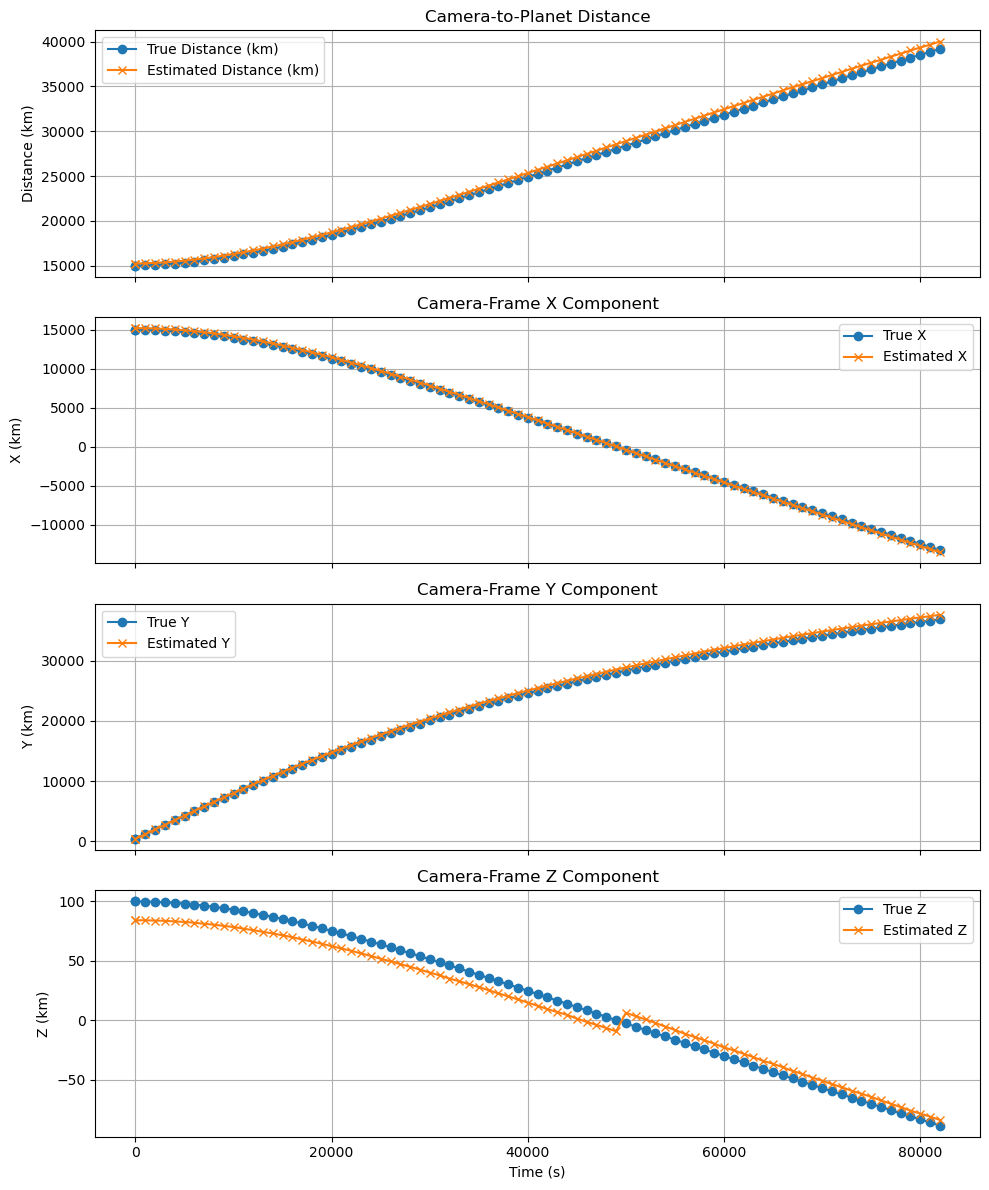

In [22]:
# compare true/estimated camera-frame vectors and distances with optional axis limits
states = np.array(states)
pos = states[:, 0:3]
estimates = np.array(estimates)
times = np.array(times)

print(np.shape(pos))
print(estimates[:, 1])
print("times:", times)



plot_est_dist_xyz(
    times,
    pos,
    estimates,
    
)

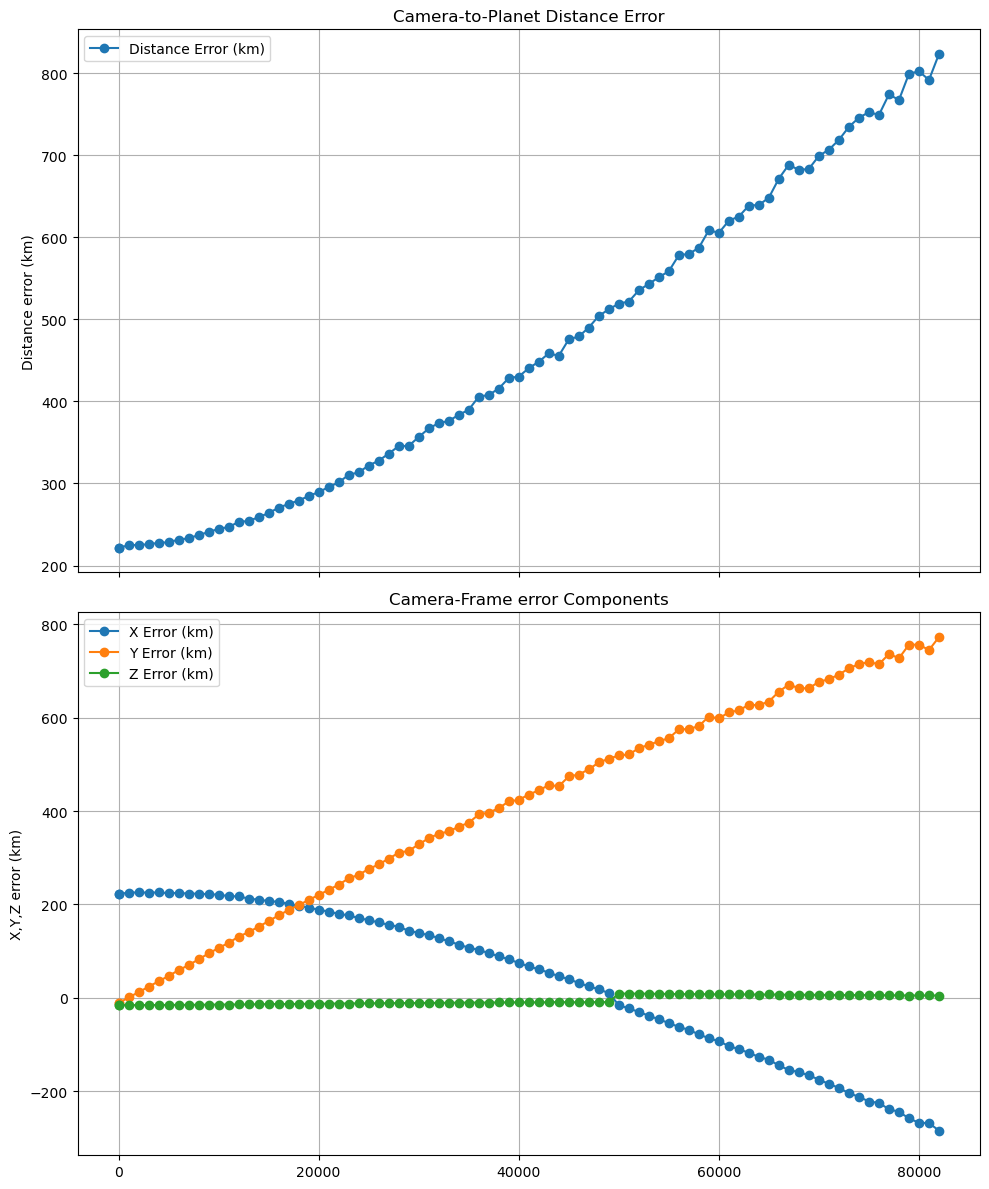

In [23]:
plot_est_dist_xyz_errors(
    times,
    pos,
    estimates,
)

In [ ]:
# EKF time
Q = np.diag([0, 0.0, 0.0, 0, 0, 0])  # Process noise covariance
R = np.diag([100.0, 100.0, 100.0])  # Measurement noise covariance
dt = 100.0  # Time step in seconds

mu0 = State0
sigma0 = np.diag([100.0, 100.0, 100.0, 1.0, 1.0, 1.0])  # Initial state covariance

central_body_mass = 7.34767309e22

ekf = SatEKF(Q, R, dt, mu0, sigma0, central_body_mass)


